# nb_01 — Prepare a DP2 subset to play with

Goal (see `docs/SPEC_V01.md`, rough plan step 1): visualize the DP2 `diaObject` footprint
(coverage and cadence), pick a handful of fields by eye from those maps, keep only objects
with more than 10 `diaSources` in each, and save that small subset to a shared location so
workshop participants can work with it directly instead of touching the full ~5 TB collection.

**Environment note (RSP notebook aspect):** this repo's `pyproject.toml` is pinned to Python
3.14 to mirror a local conda env, but the RSP kernel runs Python 3.13.9 with `lsdb`/`hats`
already provided by the stack. We do **not** `pip install .` here — we only need the
`datapaths` package on top of the stack, installed directly:

```bash
pip install --user "datapaths[tabular] @ git+https://github.com/ShrRa/datapaths.git@main"
```

`datapaths` resolves two config files under `configs/`: the committed
`artifacts_registry.yaml`, and a machine-local `roots.local.yaml` (gitignored) that must exist
on whatever machine runs this notebook. On this RSP session it maps:

- `dp2_raw` → `/rubin/lsdb_data/dp2` (the full DP2 collections, read-only)
- `dp2_filtered` → `/deleted-sundays/shrra-ung/dp2` (an already `nDiaSources > 10` filtered
  copy of the full `diaObject` collection, ~300 GB, produced separately — see
  `~/WORK/dp2_diaObj_download.py`)
- `dp2_subset` → `~/share/trieste` (small, shareable subset — this notebook's output)
- `misc` → `~/DATA/DP2` (personal scratch)

If you're running this on a different machine, create your own `configs/roots.local.yaml`
with these four keys pointing at wherever the data actually lives there.

In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hpgeom
import pyarrow.parquet as pq
from astropy.coordinates import SkyCoord
import astropy.units as u

import lsdb
from hats.inspection.visualize_catalog import plot_healpix_map

try:
    from datapaths import Datapaths
except ModuleNotFoundError:
    import sys
    print("datapaths not found — installing it into the user site-packages...")
    !{sys.executable} -m pip install --user --quiet "datapaths[tabular] @ git+https://github.com/ShrRa/datapaths.git@main"
    from datapaths import Datapaths

In [2]:
dp = Datapaths()

for root_name in ["dp2_raw", "dp2_filtered", "dp2_subset", "misc"]:
    print(f"{root_name:12s} -> {dp['root_' + root_name]}")

dp2_raw      -> /rubin/lsdb_data/dp2
dp2_filtered -> /deleted-sundays/shrra-ung/dp2
dp2_subset   -> /home/shrra-ung/share/trieste
misc         -> /home/shrra-ung/DATA/DP2


## 1. Open the raw `diaObject` collection

`lsdb.open_catalog` on a HATS *collection* directory opens its main catalog and wires up the
default margin cache. By default it loads only the columns listed as `hats_cols_default` in
the catalog's properties file — for `dia_object_lc` that's `ra`, `dec`, `tract`,
`diaObjectId`, `nDiaSources`, and the two nested light-curve columns `diaSource` and
`diaObjectForcedSource` (each a struct-of-lists, one entry per epoch).

There are also ~190 flat per-band summary columns on disk (`u_psfFluxMean`,
`g_scienceFluxMean`, min/max, etc.) that are *not* loaded unless requested via
`columns=[...]` — worth remembering for nb_02's histogram work, since those summary stats
might be more informative than raw diff fluxes for some of the questions there.

In [3]:
dia_object_cat = lsdb.open_catalog(dp["dp2_raw"] / "dia_object_collection")

print(type(dia_object_cat))
print("npartitions:", dia_object_cat.npartitions)
print("default columns:", list(dia_object_cat.columns))

<class 'lsdb.catalog.catalog.Catalog'>
npartitions: 8393
default columns: ['dec', 'diaObjectId', 'nDiaSources', 'ra', 'tract', 'diaObjectForcedSource', 'diaSource']


## 2. Visualize coverage and cadence across the whole footprint

`lsdb`'s built-in `catalog.plot_pixels()` gives a coverage map for free — it colors each
HEALPix tile by its partition order, which HATS picks adaptively so that denser sky (more
objects) gets split into finer tiles. That's our "population" map.

For a "cadence/depth" map, the natural move would be the survey property (`healsparse`) maps
from the `203_Maps` tutorial — but those go through `lsst.daf.butler`, which isn't installed
in this kernel (only in the separate "LSST" JupyterLab kernel we're not running). Instead we
build our own, Butler-free proxy from `/rubin/lsdb_data/dp2/public-files/visit_detector.parquet`
(per-visit, per-detector metadata — no Butler needed): r-band exposures are a fixed ~30s, so
**the number of r-band visits covering a spot on the sky is a direct stand-in for coadd
depth there**. We bin visit centers into the same HEALPix order as the map below and count
distinct visits per pixel.

Both maps use the same Mollweide (`MOL`) projection, so they're directly comparable side by
side — unlike the tutorial's `skyproj` maps, which default to a different one.

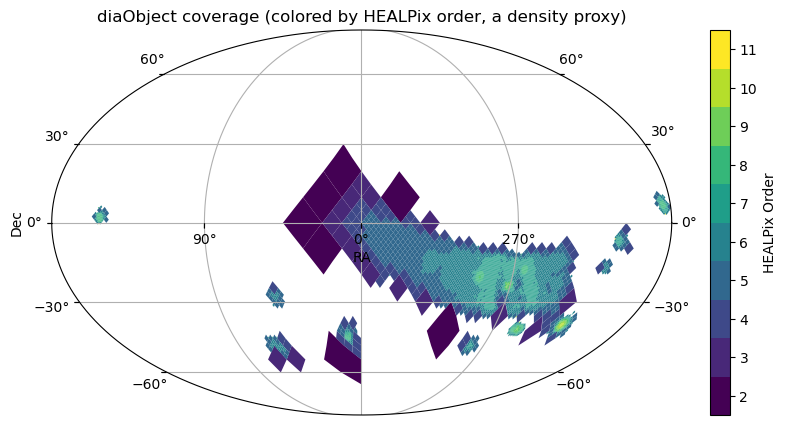

In [4]:
fig, ax = dia_object_cat.plot_pixels(
    plot_title="diaObject coverage (colored by HEALPix order, a density proxy)"
)

30339 order-7 pixels have r-band coverage


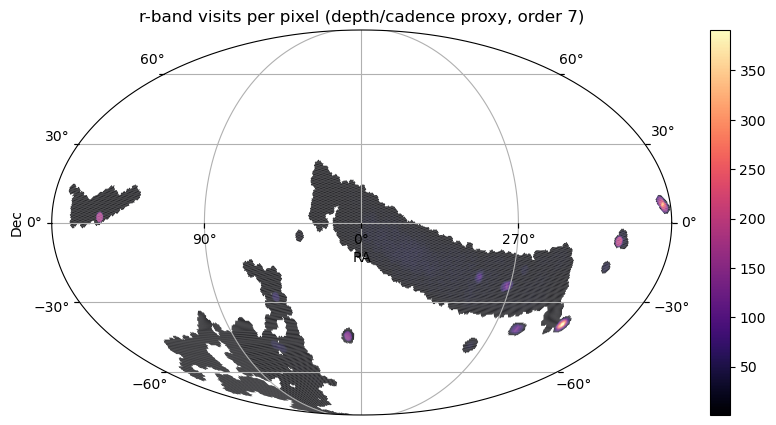

In [5]:
VISIT_MAP_ORDER = 7  # same order used for the field lookups below

visit_cols = ["visitId", "band", "ra", "dec"]
visits = pd.read_parquet(dp["dp2_raw"] / "public-files" / "visit_detector.parquet", columns=visit_cols)
r_visits = visits[visits["band"] == "r"].dropna(subset=["ra", "dec"])

nside = 2 ** VISIT_MAP_ORDER
r_pixel = hpgeom.angle_to_pixel(nside, r_visits["ra"].to_numpy(), r_visits["dec"].to_numpy(), nest=True)
visits_per_pixel = r_visits.assign(pixel=r_pixel).groupby("pixel")["visitId"].nunique()

print(f"{len(visits_per_pixel)} order-{VISIT_MAP_ORDER} pixels have r-band coverage")

fig, ax = plot_healpix_map(
    visits_per_pixel.to_numpy(),
    ipix=visits_per_pixel.index.to_numpy(),
    # a scalar `depth` triggers a panic in this cdshealpix build; an array works around it
    depth=np.full(len(visits_per_pixel), VISIT_MAP_ORDER),
    projection="MOL",
    cmap="magma",
    title="r-band visits per pixel (depth/cadence proxy, order 7)",
)

## 3. Pick your own fields

This is the point of the two maps above: eyeball them, note the (ra, dec) of whatever spots
look interesting, and list them below — nothing downstream depends on the coordinates being
"correct" in any sense, only on the field existing in the coverage map.

The 5 below were picked by eye off the depth map, without cross-checking what's officially
there — they're just coordinates, not claimed field identities. A quick sanity check (nearest
existing partition + `nDiaSources > 10` filter) beforehand showed 4 of them land on
reasonably well-observed sky (hundreds to thousands of survivors); `field_4` is deliberately
kept even though it's thin (31 objects at the nearest partition) — a sparse field is a useful
contrast case, not a mistake to avoid.

In [6]:
FIELDS = [
    ("field_1", 5, -2),
    ("field_2", 320, -16),
    ("field_3", 255, -30),
    ("field_4", 235, -33),  # deliberately sparse, kept as a contrast case
    ("field_5", 12, -45),
]
RADIUS_ARCSEC = 0.3 * 3600  # 0.3 deg; see timing note in section 4

fields_df = pd.DataFrame(FIELDS, columns=["name", "ra", "dec"])
field_coords = SkyCoord(ra=fields_df["ra"].to_numpy() * u.deg, dec=fields_df["dec"].to_numpy() * u.deg)
fields_df["gal_b"] = field_coords.galactic.b.deg
fields_df

,name,ra,dec,gal_b
0,field_1,5,-2,-63.767066
1,field_2,320,-16,-39.957556
2,field_3,255,-30,7.595828
3,field_4,235,-33,17.765093
4,field_5,12,-45,-72.115038


## 4. Filter each field to `nDiaSources > 10` and combine into one subset

`cone_search` (not `pixel_search`) here, since we want an actual circular aperture around
each arbitrary coordinate, not whatever HEALPix tile happens to contain it. We run each
field's `cone_search` + filter + `compute()` separately, `pd.concat` the small resulting
pandas tables, then hand the combined table to `lsdb.from_dataframe` (meant for exactly this:
small, in-memory data — safe well under its "<1M rows / <1GB" guidance here) to get back a
proper `lsdb.Catalog` to write.

**Performance note, checked before settling on `RADIUS_ARCSEC` above:** `cone_search` cost
scales with radius and local density, not with the size of the full collection — these 5
fields at 0.3° took ~15 s total end to end. The same field near the galactic plane at 0.75°
pulled >170,000 objects and took ~2 minutes — start with a small radius and grow it
deliberately if you want more per field, rather than defaulting to something large.

In [7]:
frames = []
for name, ra_, dec_ in FIELDS:
    field_cat = dia_object_cat.cone_search(ra=ra_, dec=dec_, radius_arcsec=RADIUS_ARCSEC)
    field_cat = field_cat.query("nDiaSources > 10")
    field_df = field_cat.compute()
    field_df["field"] = name
    print(f"{name:8s} ra={ra_:6.1f} dec={dec_:6.1f} -> {len(field_df):5d} objects")
    frames.append(field_df)

combined_df = pd.concat(frames)
print(f"\n{len(combined_df):,} objects total across {len(FIELDS)} fields")

subset_cat = lsdb.from_dataframe(combined_df)
subset_cat

Computing Catalog:   0%|          | 0/3 [00:00<?, ?it/s]

field_1  ra=   5.0 dec=  -2.0 ->   106 objects


Computing Catalog:   0%|          | 0/9 [00:00<?, ?it/s]

field_2  ra= 320.0 dec= -16.0 ->   830 objects


Computing Catalog:   0%|          | 0/12 [00:00<?, ?it/s]

...

Computing Catalog:   0%|          | 0/3 [00:00<?, ?it/s]

field_4  ra= 235.0 dec= -33.0 ->    14 objects


Computing Catalog:   0%|          | 0/12 [00:00<?, ?it/s]

field_5  ra=  12.0 dec= -45.0 ->   566 objects

7,036 objects total across 5 fields


,dec,diaObjectId,nDiaSources,ra,tract,diaObjectForcedSource,diaSource,field
npartitions=4,,,,,,,,
"Order: 1, Pixel: 17",double[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],int64[pyarrow],"nested<band: [string], coord_dec: [double], co...","nested<band: [string], centroid_flag: [bool], ...",string[pyarrow]
"Order: 1, Pixel: 34",...,...,...,...,...,...,...,...
"Order: 1, Pixel: 41",...,...,...,...,...,...,...,...
"Order: 1, Pixel: 47",...,...,...,...,...,...,...,...


In [8]:
subset_path = dp["dp2_subset"] / "dia_object_lc_10plus"

subset_cat.write_catalog(
    subset_path,
    overwrite=True,
    create_thumbnail=False,
    progress_bar=False,
)
print("wrote subset catalog to", subset_path)

wrote subset catalog to /home/shrra-ung/share/trieste/dia_object_lc_10plus


### Close the loop: what did we actually get?

Re-open the written subset and run the same `plot_pixels()` we used to survey the full
collection in section 2 — this confirms where the 5 picks actually landed, and is the whole
point of the exercise: change `FIELDS` in section 3, rerun sections 3-4, and this plot tells
you immediately whether you got what you meant to.

**Caveat:** `lsdb.from_dataframe` tiles this small a catalog at order 1 (~29° pixels), so the
plot shows big wedges, not the actual 0.3° circular apertures — don't read the wedge size as
the selected area, just the general location.

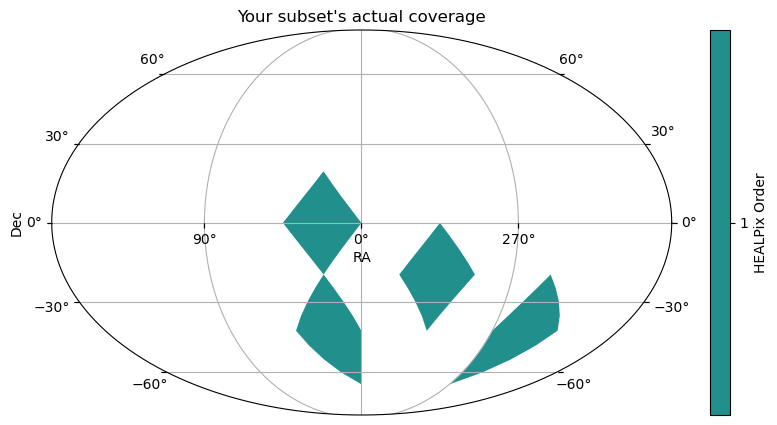

In [9]:
reopened = lsdb.open_catalog(dp["dp2_subset"] / "dia_object_lc_10plus")

fig, ax = reopened.plot_pixels(plot_title="Your subset's actual coverage")

### Registering the subset with `datapaths`

`dp.register`/`dp.save` hash and track a single *file*, not a directory tree — a written HATS
collection is a few hundred parquet files plus properties/metadata files. So instead of
registering the whole tree, we register its `collection.properties` file as a named pointer:
this gets it a `name`, a hash (of that one small file — good enough to notice if the subset
was regenerated), tags and notes in the committed registry, and makes it show up in
`dp.list()`/`dp.print_paths()`. To actually **open** the catalog in later notebooks, resolve
the root and append the same relative path used here (`dp["dp2_subset"] / "dia_object_lc_10plus"`),
same as this notebook does — the registry entry is provenance, not the access path.

In [10]:
dp.register(
    name="dia_object_lc_10plus",
    type="dp2_subset",
    fmt="hats-collection",
    src_path=str(subset_path / "collection.properties"),
    tags=["nb01", "dp2", "diaObject"],
    notes=(
        f"{len(FIELDS)} fields picked by eye off the coverage/cadence maps, {RADIUS_ARCSEC/3600:g} deg "
        "cone_search radius each, nDiaSources > 10, see nb_01 sections 2-4."
    ),
    overwrite_history=True,
)
dp.print_paths(name="dia_object_lc_10plus")

name                 | path                                                                     | tags               | type       | updated at               
---------------------+--------------------------------------------------------------------------+--------------------+------------+--------------------------
dia_object_lc_10plus | /home/shrra-ung/share/trieste/dia_object_lc_10plus/collection.properties | diaobject,dp2,nb01 | dp2_subset | 2026-08-27T18:13:42+00:00


## 5. Read the subset back, convert to pandas/numpy

`reopened` (opened above to draw the coverage plot) exercises the same `datapaths` + `lsdb`
path everyone else will use to read this subset. `.compute()` turns the (small, one partition
per field) lazy `lsdb.Catalog` into an in-memory `nested_pandas.NestedFrame` — a pandas
`DataFrame` subclass where the nested light-curve columns hold one array/list per row.
Dropping those nested columns gives an ordinary flat `pandas.DataFrame`; pulling a single
column out gives a plain `numpy` array as usual.

In [11]:
nested_df = reopened.compute()
print(type(nested_df), nested_df.shape)

flat_df = nested_df.drop(columns=["diaSource", "diaObjectForcedSource"])
print(type(flat_df), flat_df.shape)
flat_df.head()

Computing Catalog:   0%|          | 0/4 [00:00<?, ?it/s]

<class 'nested_pandas.nestedframe.core.NestedFrame'> (7036, 8)
<class 'nested_pandas.nestedframe.core.NestedFrame'> (7036, 6)


,dec,diaObjectId,nDiaSources,ra,tract,field
_healpix_29,,,,,,
1270679180598928187,-2.250791,782336951620468792,14,5.089572,8987,field_1
1270682103385757897,-2.247409,782336882900992021,14,5.130296,8987,field_1
1270682329998243538,-2.204714,782337570095759383,13,5.197458,8987,field_1
1270683290044508523,-2.150813,782345060518723639,11,5.221493,8988,field_1
1270702537854738488,-2.256708,782336951620468772,18,5.003623,8987,field_1


In [12]:
n_dia_sources = flat_df["nDiaSources"].to_numpy()
print(type(n_dia_sources), n_dia_sources.dtype, n_dia_sources.shape)
print("min/median/max:", n_dia_sources.min(), np.median(n_dia_sources), n_dia_sources.max())

<class 'numpy.ndarray'> int64 (7036,)
min/median/max: 11 16.0 194


## 6. Building a long-format light-curve table via `explode`

Each row of `nested_df` is one object with a nested `diaSource` column holding its whole
light curve as arrays. `nested_pandas`'s `.explode(column)` turns that into a long-format
table with one row per epoch — the shape most people expect for plotting or period-finding.

Two things to watch for:
- `diaSource` itself has `ra`/`dec` columns that collide with the object-level `ra`/`dec`,
  so select only `diaObjectId` + the nested column (plus whatever flat columns you actually
  need) before exploding.
- `explode` works on an already-`compute()`d, pandas-backed frame — it's a `nested_pandas`
  method, not something you call on the lazy `lsdb.Catalog` directly.

In [13]:
example_ids = nested_df["diaObjectId"].iloc[:3]
lc_table = nested_df.loc[
    nested_df["diaObjectId"].isin(example_ids), ["diaObjectId", "diaSource"]
].explode("diaSource")

print(lc_table.shape)
lc_table[["diaObjectId", "band", "midpointMjdTai", "psfMag", "psfMagErr"]].head(10)

(41, 51)


,diaObjectId,band,midpointMjdTai,psfMag,psfMagErr
_healpix_29,,,,,
1270679180598928187,782336951620468792,y,60864.322367,21.323544,0.481068
1270679180598928187,782336951620468792,y,60866.274013,22.53841,<NA>
1270679180598928187,782336951620468792,z,60867.228772,19.224422,0.033497
1270679180598928187,782336951620468792,z,60867.290083,18.999125,0.027065
1270679180598928187,782336951620468792,z,60867.290541,18.881376,0.024493
1270679180598928187,782336951620468792,z,60867.300996,18.742361,0.021111
1270679180598928187,782336951620468792,z,60867.301454,18.727667,0.020589
1270679180598928187,782336951620468792,y,60868.347768,<NA>,<NA>
1270679180598928187,782336951620468792,i,60869.290818,18.777449,0.020279


## Next

The subset now lives at `dp["dp2_subset"] / "dia_object_lc_10plus"` (registered as
`dia_object_lc_10plus` in `configs/artifacts_registry.yaml`) and covers ~7,000 objects across
the 5 fields picked by eye in section 3. nb_02 picks up from here to build the per-object and
per-LC statistics histograms (durations, amplitudes, cadence gaps) called for in the spec.

Open questions carried forward, not resolved here:
- Whether these particular 5 fields are the ones worth using for the rest of the workshop, or
  whether people should each pick their own once they've seen the maps in section 2.
- `lsdb.from_dataframe` generates its own margin cache (5 arcsec threshold by default) for the
  combined catalog — untested so far since this project's non-goals exclude crossmatching for
  now.